# 🔧 Housing Price — Hyperparameter Tuning với Optuna
Sử dụng đúng pipeline preprocessing từ `BasicHousingPreprocessor`:
load raw → split → preprocess → encode/scale → Optuna KFold tuning → retrain → đánh giá đầy đủ + lưu pkl.

## 0. Cài đặt thư viện

In [5]:
# !pip install optuna lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn joblib --quiet

## 1. Import & Cấu hình

In [6]:
import os, sys, json, warnings, joblib
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    BasicHousingPreprocessor, ColumnDropper,
    build_preprocessing_pipeline, prepare_model_data,
    TARGET_COL, DROP_COLS,
)

# ── Paths
DATA_PATH    = PROJECT_ROOT / "data" / "raw" / "data_public.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "tuning"
MODEL_DIR     = PROJECT_ROOT / "artifacts" / "tuned_models"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparams
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_FOLDS      = 5
N_TRIALS     = 30          # tăng lên 50–100 nếu có thời gian
LOG_TARGET   = True
LOG_CLIP_MAX = 25

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)
print("✅ Import xong")


✅ Import xong


## 2. Load dữ liệu thô & Train/Test split
Split **trước** preprocessing — preprocessor chỉ `fit` trên train để tránh data leakage.

In [7]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")

train_raw, test_raw = train_test_split(df_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_raw = train_raw.reset_index(drop=True)
test_raw  = test_raw.reset_index(drop=True)
print(f"Train raw: {train_raw.shape}  |  Test raw: {test_raw.shape}")


Raw shape: (51304, 28)
Train raw: (41043, 28)  |  Test raw: (10261, 28)


## 3. Preprocessing
`BasicHousingPreprocessor` fit trên train, transform trên test. Ward dùng để fill lat/lon rồi drop.

In [8]:
preprocessor = BasicHousingPreprocessor(target_col=TARGET_COL)
train_clean  = preprocessor.fit_transform(train_raw)
test_clean   = preprocessor.transform(test_raw)

preview_drop = [c for c in DROP_COLS if c != "Location"] + ["price_per_m2"]
dropper      = ColumnDropper(preview_drop)
train_clean  = dropper.transform(train_clean)
test_clean   = dropper.transform(test_clean)

print(f"Train clean : {train_clean.shape}  |  Test clean: {test_clean.shape}")
print(f"Columns     : {train_clean.columns.tolist()}")
print(f"Missing     : train={train_clean.isnull().sum().sum()} | test={test_clean.isnull().sum().sum()}")


Train clean : (34216, 18)  |  Test clean: (8543, 18)
Columns     : ['Price', 'Area', 'Location', 'Property Type', 'Width', 'Length', 'Bedrooms', 'Bathrooms', 'Floors', 'Position', 'Direction', 'Alley Width', 'Road Type', 'Latitude', 'Longitude', 'Agent Listing Count', 'District', 'distance_to_center']
Missing     : train=0 | test=0


## 4. Tách X / y — log1p transform + Encode/Scale

In [9]:
X_train_df, y_train_raw = prepare_model_data(train_clean, target_col=TARGET_COL)
X_test_df,  y_test_raw  = prepare_model_data(test_clean,  target_col=TARGET_COL)

y_train      = np.log1p(y_train_raw) if LOG_TARGET else y_train_raw.copy()
y_test       = np.log1p(y_test_raw)  if LOG_TARGET else y_test_raw.copy()
y_train_real = y_train_raw.copy()
y_test_real  = y_test_raw.copy()

encode_pipeline = build_preprocessing_pipeline(X_train_df)
X_train = encode_pipeline.fit_transform(X_train_df, y_train)
X_test  = encode_pipeline.transform(X_test_df)

try:
    feature_names = list(encode_pipeline.named_steps["encode_scale"].get_feature_names_out())
except Exception:
    feature_names = [f"f_{i}" for i in range(X_train.shape[1])]

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train mean/std: {y_train.mean():.3f} / {y_train.std():.3f}  (log space)")
print(f"Feature sample  : {feature_names[:6]} ...")


X_train: (34216, 82)  |  X_test: (8543, 82)
y_train mean/std: 8.655 / 0.973  (log space)
Feature sample  : ['numeric__Area', 'numeric__Width', 'numeric__Length', 'numeric__Bedrooms', 'numeric__Bathrooms', 'numeric__Floors'] ...


## 5. Helper: KFold CV trên log-scale, evaluate trên real scale

In [10]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(model_class, params, X, y_log):
    """KFold CV — trả về RMSE trung bình trên real scale (expm1).
    Dùng làm objective cho Optuna (minimize).
    """
    rmse_list = []
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val   = X[tr_idx], X[val_idx]
        y_tr, y_val   = y_log[tr_idx], y_log[val_idx]
        m = model_class(**params, random_state=RANDOM_STATE)
        m.fit(X_tr, y_tr)
        pred_log  = np.clip(m.predict(X_val), 0, LOG_CLIP_MAX)
        pred_real = np.expm1(pred_log) if LOG_TARGET else pred_log
        y_val_real = np.expm1(y_val)   if LOG_TARGET else y_val
        rmse_list.append(np.sqrt(mean_squared_error(y_val_real, pred_real)))
    return np.mean(rmse_list)

# Lưu numpy arrays một lần để tránh copy lặp lại trong objective
_X = X_train
_y = y_train.values

print(f"KFold: {N_FOLDS} folds  |  N_TRIALS per model: {N_TRIALS}")
print("Mỗi trial evaluate trên real scale (expm1) → RMSE (triệu VNĐ).")


KFold: 5 folds  |  N_TRIALS per model: 30
Mỗi trial evaluate trên real scale (expm1) → RMSE (triệu VNĐ).


## 6. Tuning Random Forest

In [11]:
def rf_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth"       : trial.suggest_int("max_depth", 8, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 6),
        "max_features"    : trial.suggest_float("max_features", 0.5, 1.0),
        "n_jobs"          : -1,
    }
    return cv_rmse(RandomForestRegressor, params, _X, _y)

print("🚀 Tuning Random Forest ...")
rf_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"🏆 RF   Best CV RMSE: {rf_study.best_value:,.0f}  |  Params: {rf_study.best_params}")


🚀 Tuning Random Forest ...


Best trial: 27. Best value: 5611.28: 100%|██████████| 30/30 [11:46<00:00, 23.54s/it]

🏆 RF   Best CV RMSE: 5,611  |  Params: {'n_estimators': 150, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.7663369576722698}


## 7. Tuning Gradient Boosting

In [12]:
def gb_objective(trial):
    params = {
        "n_estimators" : trial.suggest_int("n_estimators", 100, 400, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth"    : trial.suggest_int("max_depth", 3, 9),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "subsample"    : trial.suggest_float("subsample", 0.6, 1.0),
        "max_features" : trial.suggest_float("max_features", 0.5, 1.0),
    }
    return cv_rmse(GradientBoostingRegressor, params, _X, _y)

print("🚀 Tuning Gradient Boosting ...")
gb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
gb_study.optimize(gb_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"🏆 GB   Best CV RMSE: {gb_study.best_value:,.0f}  |  Params: {gb_study.best_params}")


🚀 Tuning Gradient Boosting ...


Best trial: 23. Best value: 5534.99: 100%|██████████| 30/30 [1:46:05<00:00, 212.19s/it]

🏆 GB   Best CV RMSE: 5,535  |  Params: {'n_estimators': 400, 'learning_rate': 0.0695176069771396, 'max_depth': 9, 'min_samples_split': 9, 'subsample': 0.9013930004597839, 'max_features': 0.5547487838214666}


## 8. Tuning XGBoost

In [13]:
def xgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 500, step=50),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 10),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "objective"       : "reg:squarederror",
        "eval_metric"     : "rmse",
        "n_jobs"          : -1,
        "verbosity"       : 0,
    }
    return cv_rmse(XGBRegressor, params, _X, _y)

print("🚀 Tuning XGBoost ...")
xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"🏆 XGB  Best CV RMSE: {xgb_study.best_value:,.0f}  |  Params: {xgb_study.best_params}")


🚀 Tuning XGBoost ...


Best trial: 15. Best value: 5509.63: 100%|██████████| 30/30 [04:50<00:00,  9.69s/it]

🏆 XGB  Best CV RMSE: 5,510  |  Params: {'n_estimators': 500, 'learning_rate': 0.07044979664374335, 'max_depth': 9, 'subsample': 0.7428781249130937, 'colsample_bytree': 0.7472223931930824, 'min_child_weight': 3, 'reg_alpha': 0.01377947774693316, 'reg_lambda': 0.1790996597475695}


## 9. Tuning LightGBM

In [14]:
def lgbm_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 12),
        "num_leaves"      : trial.suggest_int("num_leaves", 20, 150),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "n_jobs"          : -1,
        "verbose"         : -1,
    }
    return cv_rmse(LGBMRegressor, params, _X, _y)

print("🚀 Tuning LightGBM ...")
lgbm_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"🏆 LGBM Best CV RMSE: {lgbm_study.best_value:,.0f}  |  Params: {lgbm_study.best_params}")


🚀 Tuning LightGBM ...


Best trial: 27. Best value: 5604.28: 100%|██████████| 30/30 [03:10<00:00,  6.34s/it]

🏆 LGBM Best CV RMSE: 5,604  |  Params: {'n_estimators': 350, 'learning_rate': 0.12696210629923765, 'max_depth': 9, 'num_leaves': 129, 'subsample': 0.9872782141801107, 'colsample_bytree': 0.8749267030008712, 'reg_alpha': 0.0004683913762801849, 'reg_lambda': 0.00010470188490845359, 'min_child_samples': 18}


## 10. Bảng xếp hạng Tuning & Lưu best params JSON

BẢNG XẾP HẠNG — BEST CV RMSE (REAL SCALE, TRIỆU VNĐ)
  #1  XGBoost                 RMSE =      5,510
  #2  Gradient Boosting       RMSE =      5,535
  #3  LightGBM                RMSE =      5,604
  #4  Random Forest           RMSE =      5,611

💾 Best params JSON saved → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\tuning/


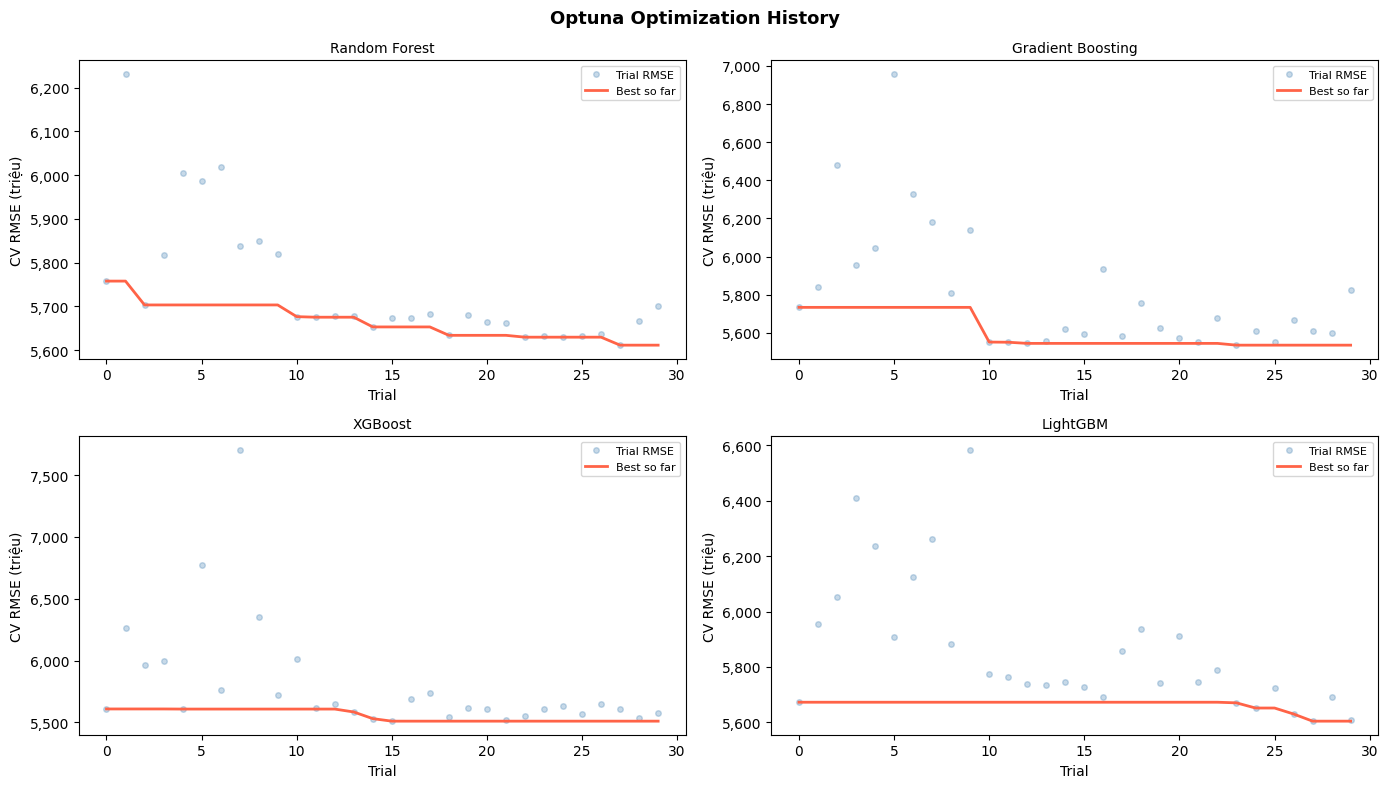

In [15]:
studies = {
    "Random Forest"    : (RandomForestRegressor,    rf_study),
    "Gradient Boosting": (GradientBoostingRegressor, gb_study),
    "XGBoost"          : (XGBRegressor,              xgb_study),
    "LightGBM"         : (LGBMRegressor,             lgbm_study),
}

tuning_summary = pd.DataFrame([
    {"Model": name, "Best CV RMSE": study.best_value, "Best Params": study.best_params}
    for name, (_, study) in studies.items()
]).sort_values("Best CV RMSE").reset_index(drop=True)
tuning_summary.index += 1

print("=" * 65)
print("BẢNG XẾP HẠNG — BEST CV RMSE (REAL SCALE, TRIỆU VNĐ)")
print("=" * 65)
for idx, row in tuning_summary.iterrows():
    print(f"  #{idx}  {row['Model']:22s}  RMSE = {row['Best CV RMSE']:>10,.0f}")

# Save best params JSON
for name, (_, study) in studies.items():
    slug = name.lower().replace(" ", "_")
    path = ARTIFACTS_DIR / f"best_params_{slug}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(study.best_params, f, indent=4, ensure_ascii=False)
print(f"\n💾 Best params JSON saved → {ARTIFACTS_DIR}/")

# Optuna optimization history plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, (_, study)) in zip(axes.flat, studies.items()):
    trials_df = study.trials_dataframe()
    best_so_far = trials_df["value"].cummin()
    ax.plot(trials_df.index, trials_df["value"], "o", alpha=0.3, ms=4, color="steelblue", label="Trial RMSE")
    ax.plot(trials_df.index, best_so_far, "-", color="tomato", lw=2, label="Best so far")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Trial"); ax.set_ylabel("CV RMSE (triệu)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(fontsize=8)
plt.suptitle("Optuna Optimization History", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 11. Retrain với best params — KFold CV đầy đủ
Retrain từng model với params tốt nhất, đánh giá KFold CV rồi test trên held-out test set.

In [16]:
metrics_list      = []
model_predictions = {}
fitted_models     = {}

for name, (model_class, study) in studies.items():
    best_params = study.best_params.copy()
    # Thêm các fixed params không nằm trong search space
    fixed = {"random_state": RANDOM_STATE}
    if name in ("Random Forest", "XGBoost", "LightGBM"):
        fixed["n_jobs"] = -1
    if name == "XGBoost":
        fixed.update({"objective": "reg:squarederror", "eval_metric": "rmse", "verbosity": 0})
    if name == "LightGBM":
        fixed["verbose"] = -1

    all_params = {**best_params, **fixed}

    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")

    cv_scores = {"MAE": [], "RMSE": [], "R2": [], "MAPE": []}
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), start=1):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train.values[tr_idx], y_train.values[val_idx]

        fm = model_class(**all_params)
        fm.fit(X_tr, y_tr)

        pred_log  = np.clip(fm.predict(X_val), 0, LOG_CLIP_MAX)
        pred_real = np.expm1(pred_log) if LOG_TARGET else pred_log
        yv_real   = np.expm1(y_val)   if LOG_TARGET else y_val

        cv_scores["MAE"].append(mean_absolute_error(yv_real, pred_real))
        cv_scores["RMSE"].append(np.sqrt(mean_squared_error(yv_real, pred_real)))
        cv_scores["R2"].append(r2_score(yv_real, pred_real))
        cv_scores["MAPE"].append(mean_absolute_percentage_error(yv_real, pred_real) * 100)
        print(f"    Fold {fold}: MAE={cv_scores['MAE'][-1]:,.0f}  "
              f"RMSE={cv_scores['RMSE'][-1]:,.0f}  "
              f"R²={cv_scores['R2'][-1]:.4f}  "
              f"MAPE={cv_scores['MAPE'][-1]:.2f}%")

    cv_mae  = np.mean(cv_scores["MAE"])
    cv_rmse = np.mean(cv_scores["RMSE"])
    cv_r2   = np.mean(cv_scores["R2"])
    cv_mape = np.mean(cv_scores["MAPE"])
    print(f"  → CV avg: MAE={cv_mae:,.0f}  RMSE={cv_rmse:,.0f}  R²={cv_r2:.4f}  MAPE={cv_mape:.2f}%")

    # Train trên toàn bộ train set
    final = model_class(**all_params)
    final.fit(X_train, y_train.values)
    fitted_models[name] = final

    # Evaluate trên test set
    pred_log  = np.clip(final.predict(X_test), 0, LOG_CLIP_MAX)
    pred_real = np.expm1(pred_log) if LOG_TARGET else pred_log

    mae  = mean_absolute_error(y_test_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
    r2   = r2_score(y_test_real, pred_real)
    mape = mean_absolute_percentage_error(y_test_real, pred_real) * 100
    print(f"  → TEST  : MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.4f}  MAPE={mape:.2f}%")

    metrics_list.append({
        "Model": name,
        "CV MAE": cv_mae,   "CV RMSE": cv_rmse,   "CV R²": cv_r2,   "CV MAPE (%)": cv_mape,
        "Test MAE": mae,    "Test RMSE": rmse,     "Test R²": r2,    "Test MAPE (%)": mape,
    })
    model_predictions[name] = {"pred_log": pred_log, "pred_real": pred_real}

metrics_df = pd.DataFrame(metrics_list)
print("\n" + "="*65)
print("BẢNG METRICS — TUNED MODELS")
print("="*65)
display(metrics_df.set_index("Model"))



────────────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────────────
    Fold 1: MAE=2,906  RMSE=5,644  R²=0.5806  MAPE=39.47%
    Fold 2: MAE=2,917  RMSE=5,653  R²=0.5780  MAPE=38.55%
    Fold 3: MAE=2,938  RMSE=5,630  R²=0.5826  MAPE=38.44%
    Fold 4: MAE=2,907  RMSE=5,540  R²=0.5845  MAPE=40.58%
    Fold 5: MAE=2,861  RMSE=5,591  R²=0.5776  MAPE=40.59%
  → CV avg: MAE=2,906  RMSE=5,611  R²=0.5807  MAPE=39.53%
  → TEST  : MAE=2,802  RMSE=5,483  R²=0.6003  MAPE=40.41%

────────────────────────────────────────────────────────────
  Gradient Boosting
────────────────────────────────────────────────────────────
    Fold 1: MAE=2,917  RMSE=5,598  R²=0.5872  MAPE=38.75%
    Fold 2: MAE=2,925  RMSE=5,561  R²=0.5916  MAPE=38.02%
    Fold 3: MAE=2,920  RMSE=5,569  R²=0.5915  MAPE=37.71%
    Fold 4: MAE=2,873  RMSE=5,420  R²=0.6023  MAPE=40.27%
    Fold 5: MAE=2,882  RMSE=5,527  R²=0.5872  MAPE=39.78%
  → CV avg: MAE=2,904 

,CV MAE,CV RMSE,CV R²,CV MAPE (%),Test MAE,Test RMSE,Test R²,Test MAPE (%)
Model,,,,,,,,
Random Forest,"2,905.983","5,611.279",0.581,39.527,"2,801.668","5,482.808",0.600,40.413
Gradient Boosting,"2,903.527","5,534.994",0.592,38.904,"2,818.111","5,429.821",0.608,40.845
XGBoost,"2,886.410","5,509.626",0.596,39.156,"2,806.875","5,420.398",0.609,41.011
LightGBM,"2,955.059","5,604.278",0.582,39.233,"2,879.658","5,489.920",0.599,40.276


## 12. So sánh Metrics — Tuned Models

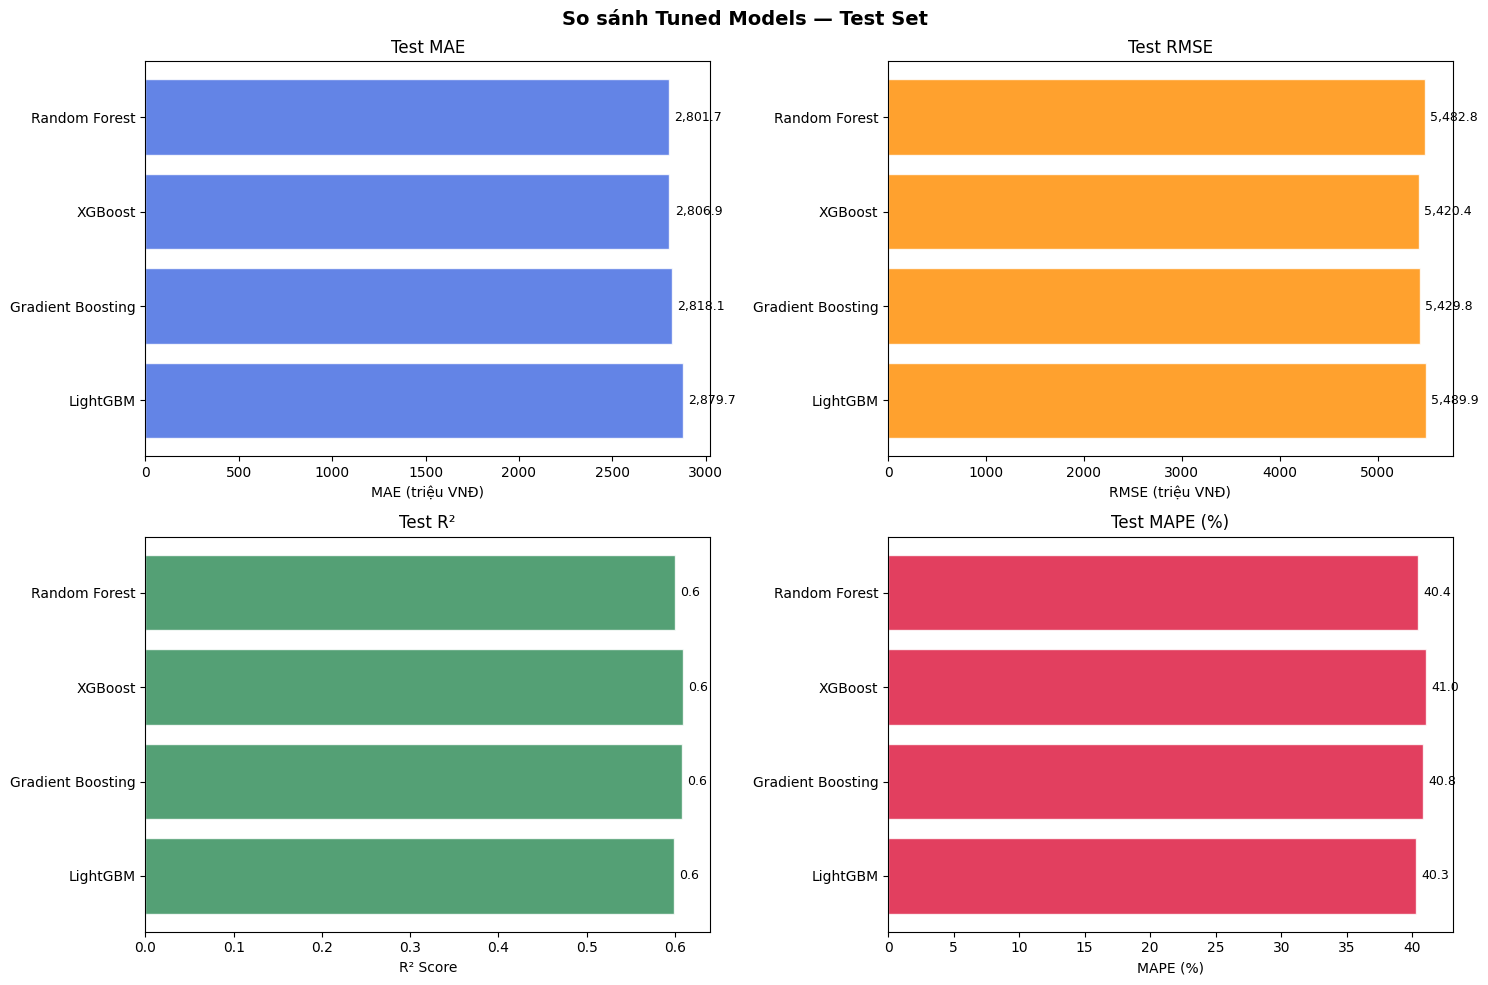

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metric_pairs = [
    ("Test MAE",      "MAE (triệu VNĐ)",   "royalblue"),
    ("Test RMSE",     "RMSE (triệu VNĐ)",  "darkorange"),
    ("Test R²",       "R² Score",           "seagreen"),
    ("Test MAPE (%)", "MAPE (%)",           "crimson"),
]
order = metrics_df.sort_values("Test MAE")["Model"].tolist()
for ax, (metric, ylabel, color) in zip(axes.flat, metric_pairs):
    vals = metrics_df.set_index("Model").loc[order, metric]
    bars = ax.barh(order, vals, color=color, alpha=0.82, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{val:,.1f}", va="center", fontsize=9)
    ax.set_xlabel(ylabel); ax.set_title(metric); ax.invert_yaxis()
plt.suptitle("So sánh Tuned Models — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 13. CV RMSE vs Test RMSE — Kiểm tra Overfit

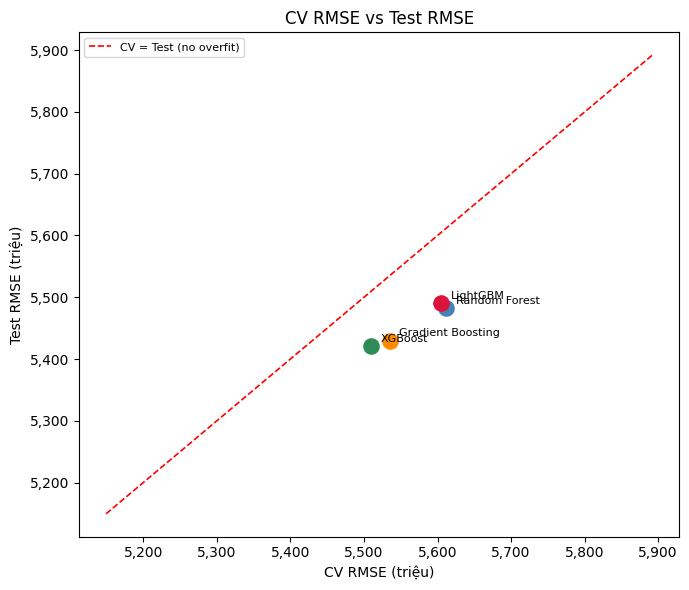

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
colors_map = {"Random Forest": "steelblue", "Gradient Boosting": "darkorange",
              "XGBoost": "seagreen", "LightGBM": "crimson"}
for _, row in metrics_df.iterrows():
    c = colors_map.get(row["Model"], "gray")
    ax.scatter(row["CV RMSE"], row["Test RMSE"], s=120, color=c, zorder=3)
    ax.annotate(row["Model"], (row["CV RMSE"], row["Test RMSE"]),
                textcoords="offset points", xytext=(7, 3), fontsize=8)

lim_lo = min(metrics_df["CV RMSE"].min(), metrics_df["Test RMSE"].min()) * 0.95
lim_hi = max(metrics_df["CV RMSE"].max(), metrics_df["Test RMSE"].max()) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--", lw=1.2, label="CV = Test (no overfit)")
ax.set_xlabel("CV RMSE (triệu)"); ax.set_ylabel("Test RMSE (triệu)")
ax.set_title("CV RMSE vs Test RMSE")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 14. Actual vs Predicted — Tuned Models

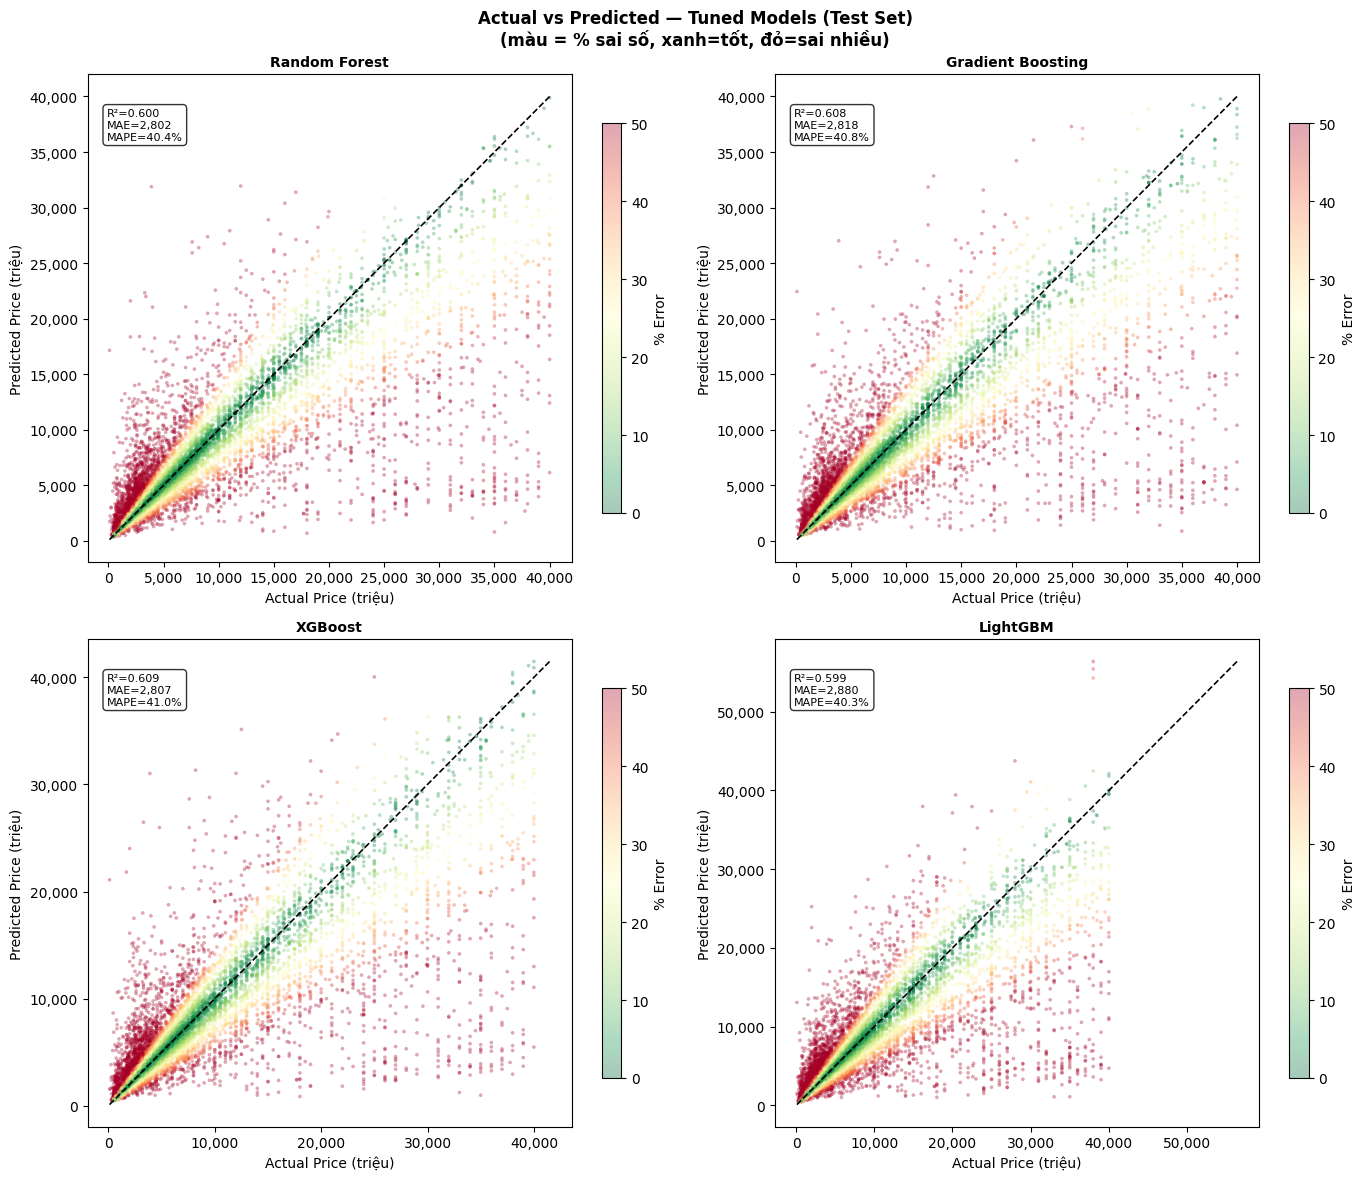

In [19]:
n_models = len(model_predictions)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flat

for ax, (name, pd_) in zip(axes, model_predictions.items()):
    y_act = y_test_real.values
    y_prd = pd_["pred_real"]

    # Scatter points — tô màu theo mức sai số tương đối
    pct_err = np.abs(y_act - y_prd) / np.where(y_act > 0, y_act, 1) * 100
    sc = ax.scatter(y_act, y_prd, c=pct_err, cmap="RdYlGn_r",
                    vmin=0, vmax=50, alpha=0.35, s=7, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="% Error", shrink=0.8)

    lo = min(y_act.min(), y_prd.min())
    hi = max(y_act.max(), y_prd.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Perfect fit")

    r2_val  = r2_score(y_act, y_prd)
    mae_val = mean_absolute_error(y_act, y_prd)
    mape_val = mean_absolute_percentage_error(y_act, y_prd) * 100
    ax.set_title(f"{name}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Actual Price (triệu)")
    ax.set_ylabel("Predicted Price (triệu)")
    ax.text(0.04, 0.93,
            f"R²={r2_val:.3f}\nMAE={mae_val:,.0f}\nMAPE={mape_val:.1f}%",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.8))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for ax in list(axes)[n_models:]: ax.set_visible(False)
plt.suptitle("Actual vs Predicted — Tuned Models (Test Set)\n(màu = % sai số, xanh=tốt, đỏ=sai nhiều)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 15. Phân phối Residuals

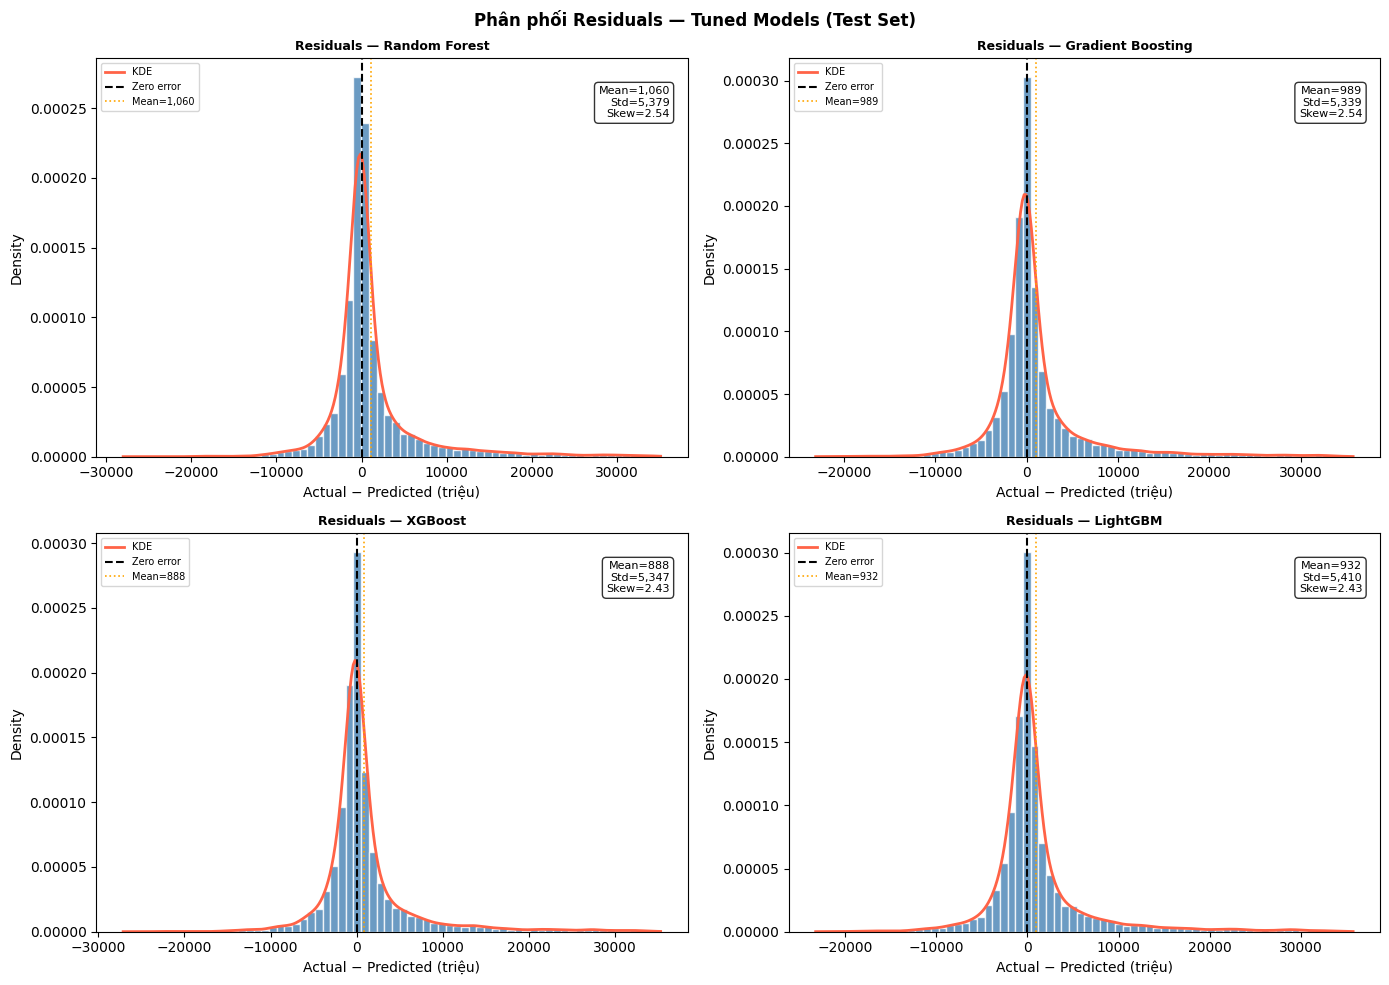

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flat

for ax, (name, pd_) in zip(axes, model_predictions.items()):
    res = y_test_real.values - pd_["pred_real"]
    # Histogram
    ax.hist(res, bins=70, color="steelblue", edgecolor="white", alpha=0.8, density=True)
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde_x = np.linspace(res.min(), res.max(), 300)
    kde   = gaussian_kde(res)(kde_x)
    ax.plot(kde_x, kde, color="tomato", lw=2, label="KDE")
    ax.axvline(0, color="black", lw=1.5, ls="--", label="Zero error")
    ax.axvline(res.mean(), color="orange", lw=1.2, ls=":", label=f"Mean={res.mean():,.0f}")
    ax.set_title(f"Residuals — {name}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Actual − Predicted (triệu)")
    ax.set_ylabel("Density")
    ax.text(0.97, 0.93,
            f"Mean={res.mean():,.0f}\nStd={res.std():,.0f}\nSkew={pd.Series(res).skew():.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.8))
    ax.legend(fontsize=7)

for ax in list(axes)[n_models:]: ax.set_visible(False)
plt.suptitle("Phân phối Residuals — Tuned Models (Test Set)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 16. MAE theo Phân khúc Giá

=== MAE theo phân khúc (triệu VNĐ) ===


Model,Gradient Boosting,LightGBM,Random Forest,XGBoost
Segment,,,,
1. < 2 tỷ,911,902,935,884
2. 2–5 tỷ,"1,251","1,232","1,264","1,285"
3. 5–10 tỷ,"1,694","1,758","1,618","1,739"
4. 10–20 tỷ,"3,493","3,698","3,337","3,523"
5. > 20 tỷ,"10,509","10,642","10,698","10,213"



=== MAPE theo phân khúc (%) ===


Model,Gradient Boosting,LightGBM,Random Forest,XGBoost
Segment,,,,
1. < 2 tỷ,99.2%,92.1%,96.5%,96.3%
2. 2–5 tỷ,39.4%,38.9%,40.4%,40.9%
3. 5–10 tỷ,24.0%,25.0%,23.1%,24.7%
4. 10–20 tỷ,24.8%,26.4%,23.8%,25.0%
5. > 20 tỷ,35.7%,36.3%,36.2%,34.8%


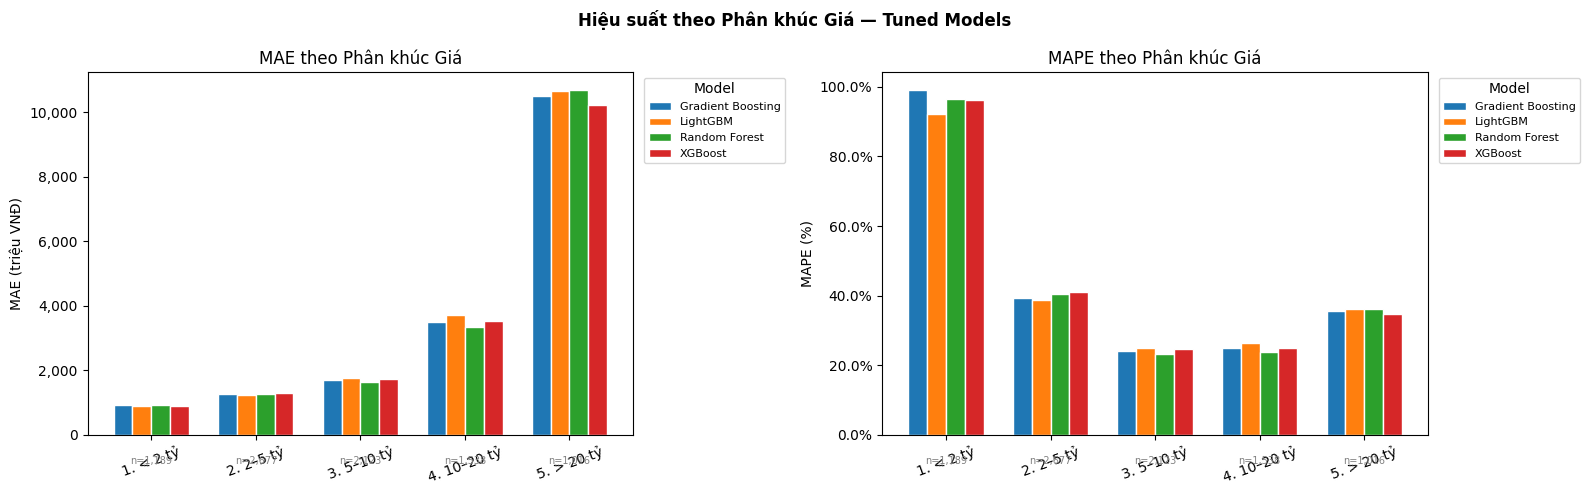

In [21]:
def price_segment(p):
    if p < 2_000:    return "1. < 2 tỷ"
    elif p < 5_000:  return "2. 2–5 tỷ"
    elif p < 10_000: return "3. 5–10 tỷ"
    elif p < 20_000: return "4. 10–20 tỷ"
    else:            return "5. > 20 tỷ"

seg_rows = []
for name, pd_ in model_predictions.items():
    df_s = pd.DataFrame({"Actual": y_test_real.values, "Pred": pd_["pred_real"]})
    df_s["Seg"] = df_s["Actual"].apply(price_segment)
    for seg, g in df_s.groupby("Seg"):
        seg_rows.append({
            "Model": name, "Segment": seg, "N": len(g),
            "MAE":  mean_absolute_error(g["Actual"], g["Pred"]),
            "MAPE": mean_absolute_percentage_error(g["Actual"], g["Pred"]) * 100,
        })

seg_df  = pd.DataFrame(seg_rows)
seg_mae = seg_df.pivot(index="Segment", columns="Model", values="MAE")
seg_mape= seg_df.pivot(index="Segment", columns="Model", values="MAPE")
seg_n   = seg_df[seg_df["Model"]==seg_df["Model"].iloc[0]].set_index("Segment")["N"]

print("=== MAE theo phân khúc (triệu VNĐ) ===")
display(seg_mae.style.format("{:,.0f}").background_gradient(cmap="YlOrRd", axis=1))

print("\n=== MAPE theo phân khúc (%) ===")
display(seg_mape.style.format("{:.1f}%").background_gradient(cmap="YlOrRd", axis=1))

# ── Grouped bar: MAE per segment
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

seg_mae.plot(kind="bar", ax=axes[0], width=0.72, edgecolor="white")
axes[0].set_ylabel("MAE (triệu VNĐ)"); axes[0].set_title("MAE theo Phân khúc Giá")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

seg_mape.plot(kind="bar", ax=axes[1], width=0.72, edgecolor="white")
axes[1].set_ylabel("MAPE (%)"); axes[1].set_title("MAPE theo Phân khúc Giá")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=20)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
axes[1].legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# Annotate number of samples per segment
for ax in axes:
    for i, seg in enumerate(seg_mae.index):
        ax.text(i, ax.get_ylim()[0] - (ax.get_ylim()[1]-ax.get_ylim()[0])*0.06,
                f"n={seg_n.get(seg,0):,}", ha="center", va="top", fontsize=7, color="gray")

plt.suptitle("Hiệu suất theo Phân khúc Giá — Tuned Models", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 17. Actual vs Predicted — Phân tách theo Phân khúc Giá

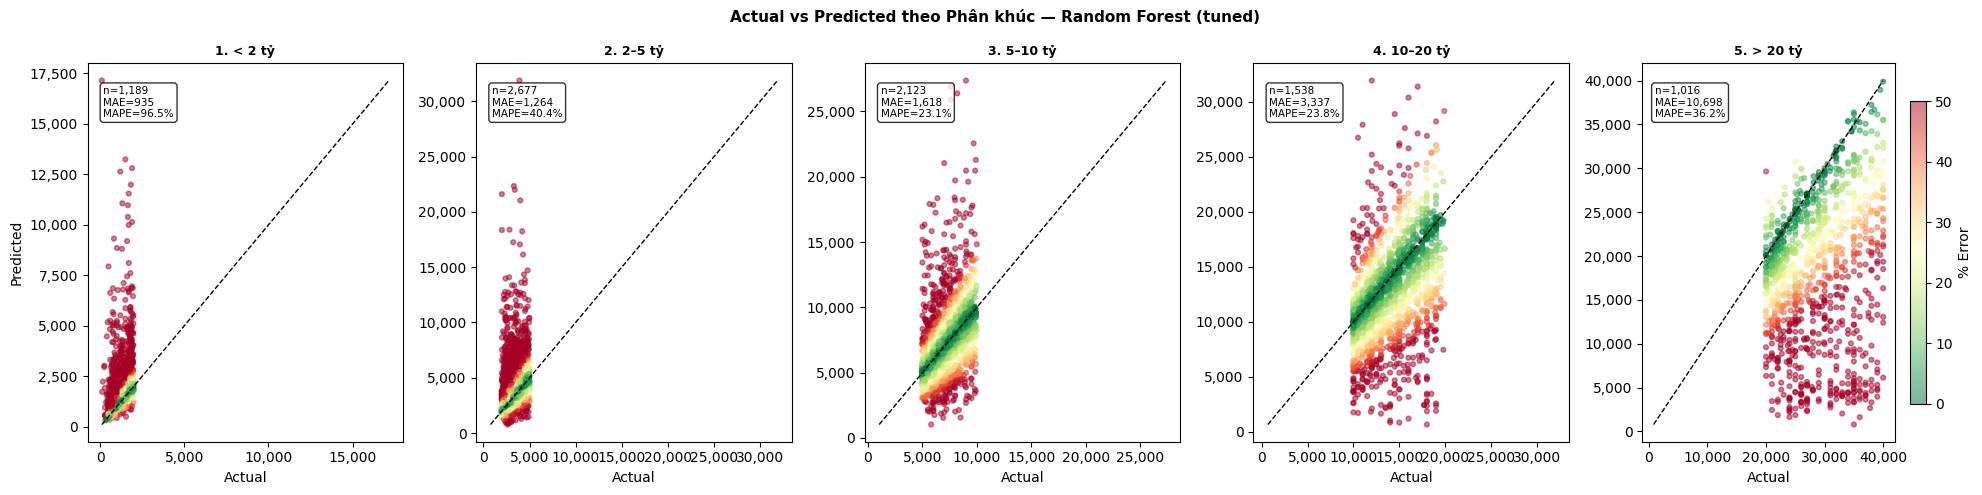

In [22]:
# Chỉ vẽ cho model tốt nhất (theo Test MAE)
best_name = metrics_df.sort_values("Test MAE").iloc[0]["Model"]
best_pred = model_predictions[best_name]["pred_real"]

df_plot = pd.DataFrame({
    "Actual"   : y_test_real.values,
    "Predicted": best_pred,
    "Segment"  : [price_segment(p) for p in y_test_real.values],
})

segments = sorted(df_plot["Segment"].unique())
n_seg = len(segments)
fig, axes = plt.subplots(1, n_seg, figsize=(4 * n_seg, 5), sharey=False)

for ax, seg in zip(axes, segments):
    sub = df_plot[df_plot["Segment"] == seg]
    pct_err = np.abs(sub["Actual"] - sub["Predicted"]) / sub["Actual"] * 100
    sc = ax.scatter(sub["Actual"], sub["Predicted"], c=pct_err,
                    cmap="RdYlGn_r", vmin=0, vmax=50, alpha=0.5, s=12)
    lo = min(sub["Actual"].min(), sub["Predicted"].min())
    hi = max(sub["Actual"].max(), sub["Predicted"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(seg, fontsize=9, fontweight="bold")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted" if seg == segments[0] else "")
    mae_s  = mean_absolute_error(sub["Actual"], sub["Predicted"])
    mape_s = mean_absolute_percentage_error(sub["Actual"], sub["Predicted"]) * 100
    ax.text(0.05, 0.94,
            f"n={len(sub):,}\nMAE={mae_s:,.0f}\nMAPE={mape_s:.1f}%",
            transform=ax.transAxes, va="top", fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.colorbar(sc, ax=axes[-1], label="% Error", shrink=0.8)
plt.suptitle(f"Actual vs Predicted theo Phân khúc — {best_name} (tuned)",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


## 18. Feature Importance — Tuned Models (Top 20)

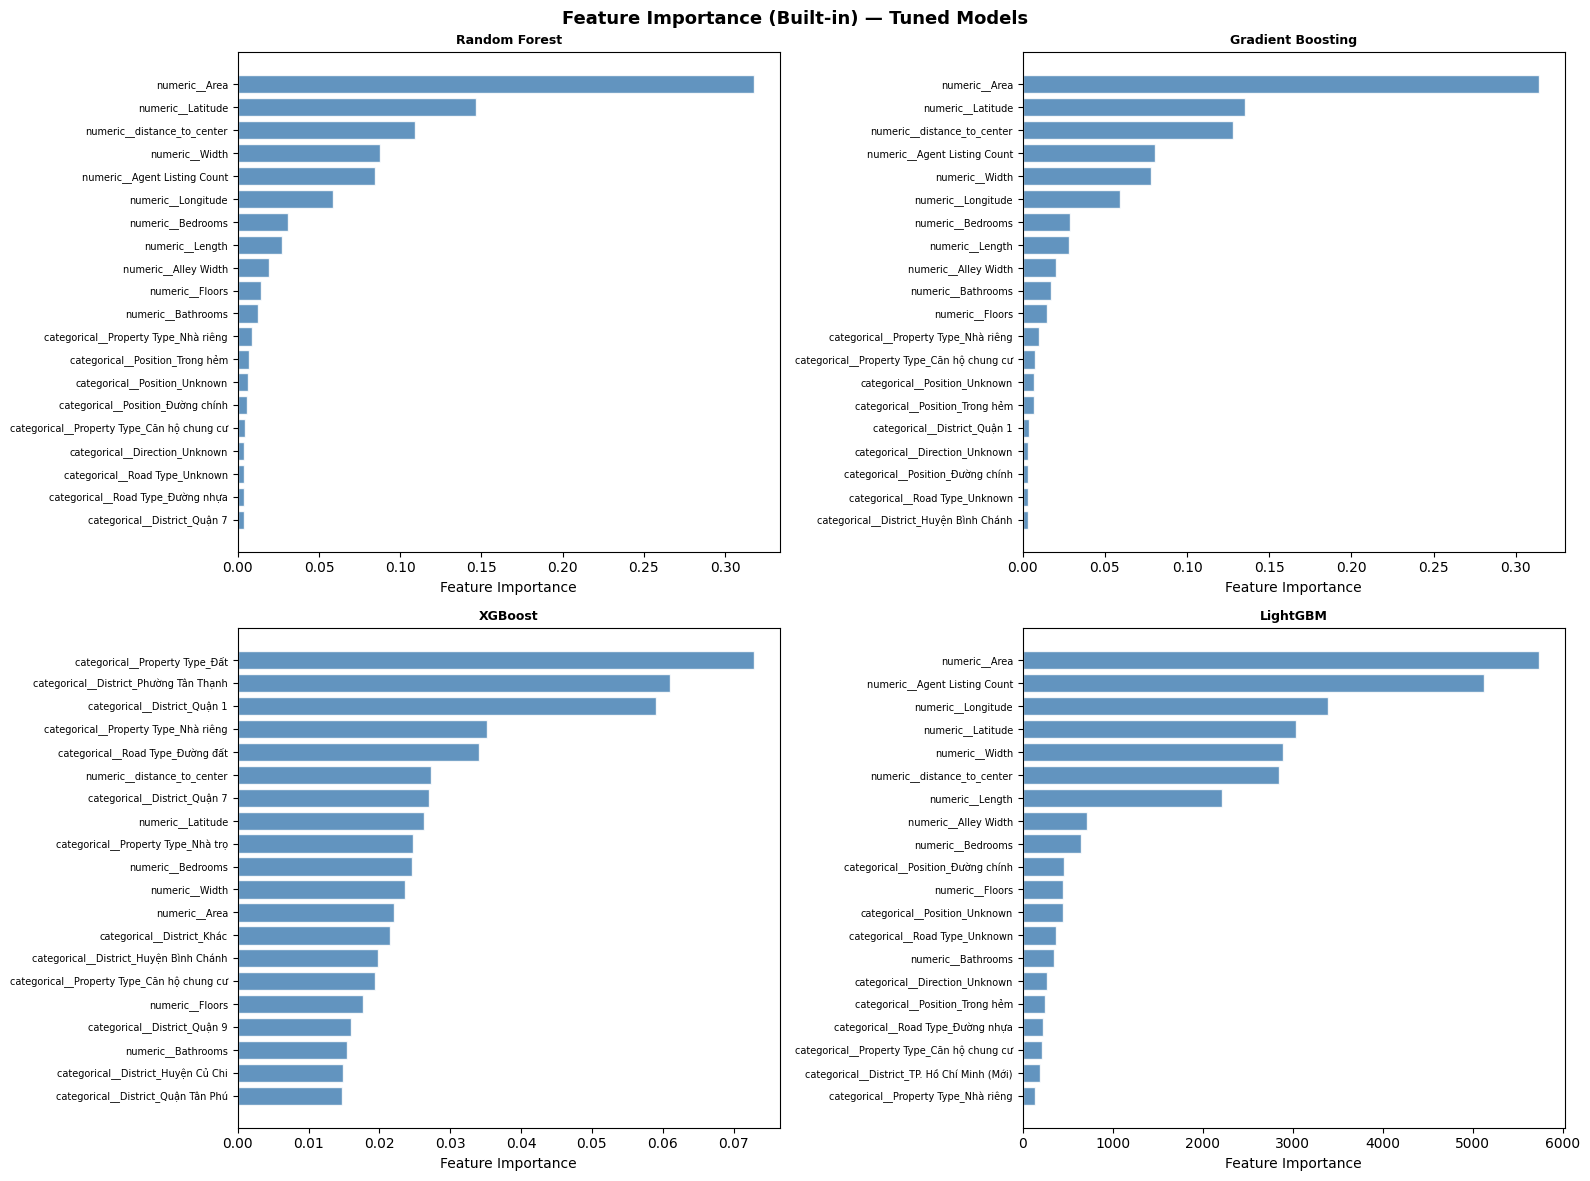

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flat

for ax, (name, mdl) in zip(axes, fitted_models.items()):
    imp = mdl.feature_importances_
    fi_df = (pd.DataFrame({"Feature": feature_names, "Importance": imp})
               .sort_values("Importance", ascending=False)
               .head(20).iloc[::-1])
    ax.barh(fi_df["Feature"], fi_df["Importance"],
            color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_title(f"{name}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Feature Importance")
    ax.tick_params(axis="y", labelsize=7)

for ax in list(axes)[len(fitted_models):]: ax.set_visible(False)
plt.suptitle("Feature Importance (Built-in) — Tuned Models", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 19. Lưu Tuned Models (pkl bundle)

In [24]:
saved_paths = {}
for name, mdl in fitted_models.items():
    slug = name.lower().replace(" ", "_")
    path = MODEL_DIR / f"tuned_{slug}.pkl"
    bundle = {
        "model"          : mdl,
        "encode_pipeline": encode_pipeline,
        "preprocessor"   : preprocessor,
        "feature_names"  : feature_names,
        "log_target"     : LOG_TARGET,
        "best_params"    : studies[name][1].best_params,
        "metrics"        : {k: v for row in metrics_list if row["Model"] == name
                             for k, v in row.items() if k != "Model"},
    }
    joblib.dump(bundle, path, compress=3)
    saved_paths[name] = path
    print(f"  ✅  {name:<22} → {path}  ({path.stat().st_size/1024:,.0f} KB)")

print("\n💾 Tất cả tuned models đã được lưu.")


  ✅  Random Forest          → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\tuned_models\tuned_random_forest.pkl  (70,560 KB)
  ✅  Gradient Boosting      → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\tuned_models\tuned_gradient_boosting.pkl  (3,561 KB)
  ✅  XGBoost                → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\tuned_models\tuned_xgboost.pkl  (2,996 KB)
  ✅  LightGBM               → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\tuned_models\tuned_lightgbm.pkl  (1,125 KB)

💾 Tất cả tuned models đã được lưu.


## 20. Verify load pkl

In [25]:
print("=== Kiểm tra load & predict ===")
for name, path in saved_paths.items():
    bundle = joblib.load(path)
    pred_log  = np.clip(bundle["model"].predict(X_test), 0, LOG_CLIP_MAX)
    pred_real = np.expm1(pred_log) if bundle["log_target"] else pred_log
    mae_loaded = mean_absolute_error(y_test_real, pred_real)
    mae_orig   = metrics_df[metrics_df["Model"] == name]["Test MAE"].values[0]
    ok = abs(mae_loaded - mae_orig) < 0.5
    print(f"  {'✅' if ok else '❌'}  {name:<22}  MAE={mae_loaded:,.0f}  (orig={mae_orig:,.0f})")


=== Kiểm tra load & predict ===
  ✅  Random Forest           MAE=2,802  (orig=2,802)
  ✅  Gradient Boosting       MAE=2,818  (orig=2,818)
  ✅  XGBoost                 MAE=2,807  (orig=2,807)
  ✅  LightGBM                MAE=2,880  (orig=2,880)


## 21. Tóm tắt kết quả

In [26]:
print("=" * 70)
print("TỔNG KẾT — TUNED MODELS (XẾP HẠNG THEO TEST MAE)")
print("=" * 70)
ranked = metrics_df.sort_values("Test MAE").reset_index(drop=True)
ranked.index += 1
for _, row in ranked.iterrows():
    print(f"  #{int(row.name):2d} 💾  {row['Model']:22s}"
          f"  MAE={row['Test MAE']:>9,.0f}"
          f"  RMSE={row['Test RMSE']:>9,.0f}"
          f"  R²={row['Test R²']:.4f}"
          f"  MAPE={row['Test MAPE (%)']:.2f}%")

best = ranked.iloc[0]
print(f"\n🏆 Best: {best['Model']}")
print(f"   MAE={best['Test MAE']:,.0f}  RMSE={best['Test RMSE']:,.0f}  R²={best['Test R²']:.4f}  MAPE={best['Test MAPE (%)']:.2f}%")
print(f"\n💾 Models dir: {MODEL_DIR.resolve()}")
print("=" * 70)


TỔNG KẾT — TUNED MODELS (XẾP HẠNG THEO TEST MAE)
  # 1 💾  Random Forest           MAE=    2,802  RMSE=    5,483  R²=0.6003  MAPE=40.41%
  # 2 💾  XGBoost                 MAE=    2,807  RMSE=    5,420  R²=0.6093  MAPE=41.01%
  # 3 💾  Gradient Boosting       MAE=    2,818  RMSE=    5,430  R²=0.6080  MAPE=40.85%
  # 4 💾  LightGBM                MAE=    2,880  RMSE=    5,490  R²=0.5992  MAPE=40.28%

🏆 Best: Random Forest
   MAE=2,802  RMSE=5,483  R²=0.6003  MAPE=40.41%

💾 Models dir: C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\tuned_models
